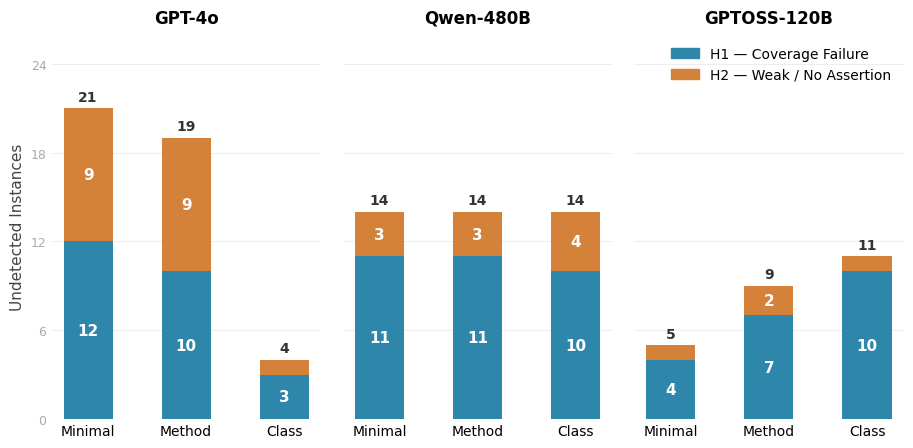

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

H1_COLOR = '#2E86AB'
H2_COLOR = '#D4813A'

data = [
    dict(model='GPT-4o',      variant='Minimal', H1=12, H2=9),
    dict(model='GPT-4o',      variant='Method',  H1=10, H2=9),
    dict(model='GPT-4o',      variant='Class',   H1=3,  H2=1),
    dict(model='Qwen-480B',   variant='Minimal', H1=11, H2=3),
    dict(model='Qwen-480B',   variant='Method',  H1=11, H2=3),
    dict(model='Qwen-480B',   variant='Class',   H1=10, H2=4),
    dict(model='GPTOSS-120B', variant='Minimal', H1=4,  H2=1),
    dict(model='GPTOSS-120B', variant='Method',  H1=7,  H2=2),
    dict(model='GPTOSS-120B', variant='Class',   H1=10, H2=1),
]

MODELS   = ['GPT-4o', 'Qwen-480B', 'GPTOSS-120B']
VARIANTS = ['Minimal', 'Method', 'Class']

fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharey=True)
plt.subplots_adjust(wspace=0.08)

x      = np.arange(len(VARIANTS))
bar_w  = 0.5

for ax, model in zip(axes, MODELS):
    model_data = [d for d in data if d['model'] == model]
    h1_vals = [d['H1'] for d in model_data]
    h2_vals = [d['H2'] for d in model_data]

    ax.bar(x, h1_vals, width=bar_w, color=H1_COLOR, linewidth=0, zorder=3)
    ax.bar(x, h2_vals, width=bar_w, bottom=h1_vals,
           color=H2_COLOR, linewidth=0, zorder=3)

    for i, (h1, h2) in enumerate(zip(h1_vals, h2_vals)):
        total = h1 + h2

        # H1 label inside — only if segment tall enough
        if h1 >= 2:
            ax.text(i, h1 / 2, str(h1),
                    ha='center', va='center',
                    color='white', fontsize=11, fontweight='bold')

        # H2 label inside — only if segment tall enough
        if h2 >= 2:
            ax.text(i, h1 + h2 / 2, str(h2),
                    ha='center', va='center',
                    color='white', fontsize=11, fontweight='bold')

        # total always on top
        ax.text(i, total + 0.3, str(total),
                ha='center', va='bottom',
                color='#333', fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(VARIANTS, fontsize=10)
    ax.set_title(model, fontsize=12, fontweight='bold', pad=8)

    # clean look
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)
    ax.grid(axis='y', color='#eeeeee', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.yaxis.set_tick_params(labelcolor='#aaa', labelsize=9)

axes[0].set_ylabel('Undetected Instances', fontsize=11, color='#444')
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
axes[0].set_ylim(0, 26)

# legend top right of last panel
axes[2].legend(
    handles=[
        mpatches.Patch(color=H1_COLOR, label='H1 — Coverage Failure'),
        mpatches.Patch(color=H2_COLOR, label='H2 — Weak / No Assertion'),
    ],
    loc='upper right', fontsize=10, frameon=False
)



plt.savefig('h1h2_instance_level.pdf', bbox_inches='tight', dpi=300)
plt.savefig('h1h2_instance_level.png', bbox_inches='tight', dpi=300)
plt.show()

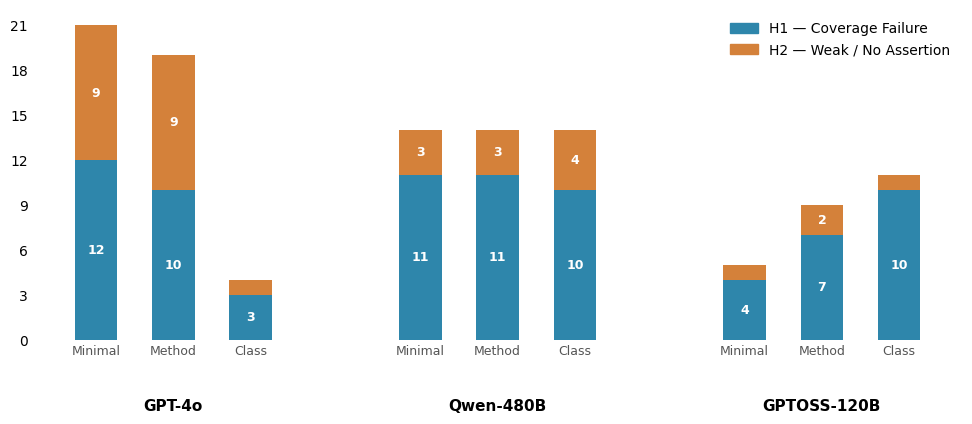

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

H1_COLOR = '#2E86AB'
H2_COLOR = '#D4813A'

data = [
    dict(model='GPT-4o',      variant='Minimal', H1=12, H2=9),
    dict(model='GPT-4o',      variant='Method',  H1=10, H2=9),
    dict(model='GPT-4o',      variant='Class',   H1=3,  H2=1),
    dict(model='Qwen-480B',   variant='Minimal', H1=11, H2=3),
    dict(model='Qwen-480B',   variant='Method',  H1=11, H2=3),
    dict(model='Qwen-480B',   variant='Class',   H1=10, H2=4),
    dict(model='GPTOSS-120B', variant='Minimal', H1=4,  H2=1),
    dict(model='GPTOSS-120B', variant='Method',  H1=7,  H2=2),
    dict(model='GPTOSS-120B', variant='Class',   H1=10, H2=1),
]

MODELS   = ['GPT-4o', 'Qwen-480B', 'GPTOSS-120B']
VARIANTS = ['Minimal', 'Method', 'Class']

fig, ax = plt.subplots(figsize=(12,5))

bar_w = 0.55
group_gap = 1.2

# compute x positions
positions = []
x = 0
group_centers = []

for model in MODELS:
    start = x
    for variant in VARIANTS:
        positions.append((model, variant, x))
        x += 1
    group_centers.append((start + x - 1) / 2)
    x += group_gap

pos_map = {(m,v):p for m,v,p in positions}

# plot bars
for d in data:

    x = pos_map[(d['model'], d['variant'])]
    h1, h2 = d['H1'], d['H2']

    ax.bar(x, h1, width=bar_w, color=H1_COLOR, zorder=3)
    ax.bar(x, h2, width=bar_w, bottom=h1, color=H2_COLOR, zorder=3)

    if h1 >= 2:
        ax.text(x, h1/2, str(h1),
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

    if h2 >= 2:
        ax.text(x, h1 + h2/2, str(h2),
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

# variant ticks
variant_ticks = [p for _,_,p in positions]
ax.set_xticks(variant_ticks)
ax.set_xticklabels(VARIANTS * len(MODELS), fontsize=9, color='#555')

# model labels (axis transform prevents clipping)
for cx, model in zip(group_centers, MODELS):
    ax.text(cx, -0.18, model,
            ha='center', va='top',
            transform=ax.get_xaxis_transform(),
            fontsize=11, fontweight='bold')

# # vertical separators
# for i in range(1, len(group_centers)):
#     sep = (group_centers[i] + group_centers[i-1]) / 2 + 0.5
#     ax.axvline(sep, color='#e6e6e6', linestyle='--', lw=1)

# styling
# ax.set_ylim(0, 26)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# ax.set_ylabel('Undetected Instances', fontsize=11, color='#444')

# ax.grid(axis='y', color='#efefef')
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

ax.legend(
    handles=[
        mpatches.Patch(color=H1_COLOR, label='H1 — Coverage Failure'),
        mpatches.Patch(color=H2_COLOR, label='H2 — Weak / No Assertion'),
    ],
    loc='upper right',
    frameon=False
)


plt.subplots_adjust(bottom=0.22)

plt.savefig('h1h2_instance_level.pdf', dpi=300, bbox_inches='tight')
plt.savefig('h1h2_instance_level.png', dpi=300, bbox_inches='tight')

plt.show()

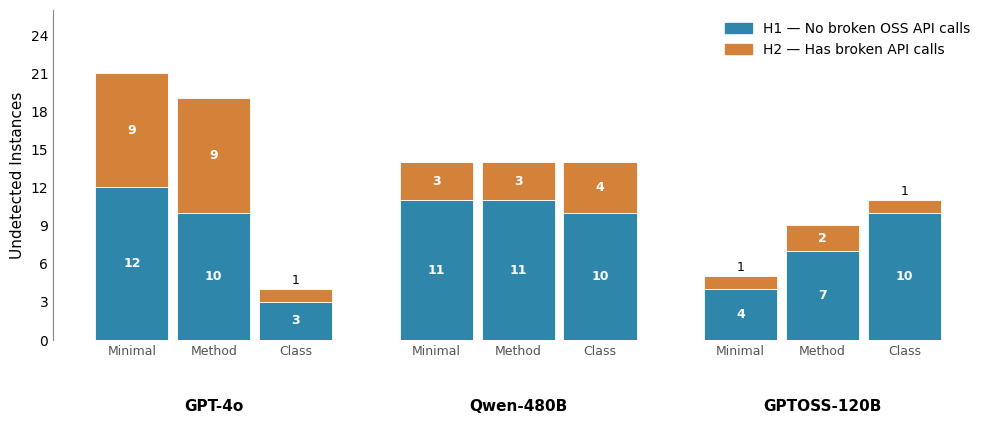

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

H1_COLOR = '#2E86AB'
H2_COLOR = '#D4813A'

data = {
    'GPT-4o': {
        'Minimal': (12,9),
        'Method': (10,9),
        'Class': (3,1)
    },
    'Qwen-480B': {
        'Minimal': (11,3),
        'Method': (11,3),
        'Class': (10,4)
    },
    'GPTOSS-120B': {
        'Minimal': (4,1),
        'Method': (7,2),
        'Class': (10,1)
    }
}

MODELS   = list(data.keys())
VARIANTS = ['Minimal','Method','Class']

fig, ax = plt.subplots(figsize=(12,5))

bar_w = 0.6
variant_offsets = np.array([-1.12, 0, 1.12]) * bar_w
group_spacing = 2.5

x = np.arange(len(MODELS)) * group_spacing

for i, variant in enumerate(VARIANTS):

    xs = x + variant_offsets[i]

    h1 = [data[m][variant][0] for m in MODELS]
    h2 = [data[m][variant][1] for m in MODELS]

    ax.bar(xs, h1,
           width=bar_w,
           color=H1_COLOR,
           edgecolor='white',
           linewidth=0.6,
           zorder=3)

    ax.bar(xs, h2,
           bottom=h1,
           width=bar_w,
           color=H2_COLOR,
           edgecolor='white',
           linewidth=0.6,
           zorder=3)

    for xi, a, b in zip(xs, h1, h2):

        if a >= 2:
            ax.text(xi, a/2, str(a),
                    ha='center', va='center',
                    color='white', fontsize=9, fontweight='bold')
        elif a > 0:
            ax.text(xi, a+0.2, str(a),
                    ha='center', va='bottom', fontsize=9)

        if b >= 2:
            ax.text(xi, a + b/2, str(b),
                    ha='center', va='center',
                    color='white', fontsize=9, fontweight='bold')
        elif b > 0:
            ax.text(xi, a + b + 0.2, str(b),
                    ha='center', va='bottom', fontsize=9)

# variant labels
xticks = []
xticklabels = []

for i in range(len(MODELS)):
    for j in range(len(VARIANTS)):
        xticks.append(x[i] + variant_offsets[j])
        xticklabels.append(VARIANTS[j])

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=9, color='#555')

# model labels
for xi, model in zip(x, MODELS):
    ax.text(xi, -0.18, model,
            transform=ax.get_xaxis_transform(),
            ha='center', va='top',
            fontsize=11, fontweight='bold')

# y-axis
ax.set_ylim(0,26)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel('Undetected Instances', fontsize=11)

# grid
# ax.grid(axis='y', color='#efefef')
ax.set_axisbelow(True)

# spines
for s in ['top','right','bottom']:
    ax.spines[s].set_visible(False)

ax.spines['left'].set_color('#888')
ax.spines['left'].set_linewidth(0.8)

ax.tick_params(length=0)

# legend
ax.legend(
    handles=[
        mpatches.Patch(color=H1_COLOR, label='H1 — No broken OSS API calls'),
        mpatches.Patch(color=H2_COLOR, label='H2 — Has broken API calls')
    ],
    frameon=False,
    loc='upper right'
)

plt.subplots_adjust(bottom=0.22)

plt.savefig("h1h2_instance_level.pdf", dpi=300, bbox_inches="tight")
plt.savefig("h1h2_instance_level.png", dpi=300, bbox_inches="tight")

plt.show()

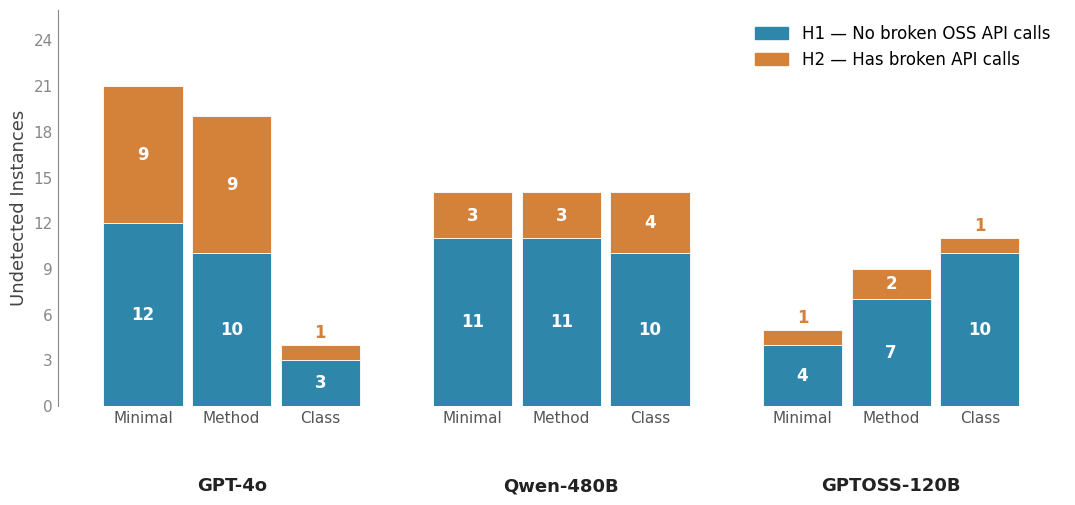

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

H1_COLOR = '#2E86AB'
H2_COLOR = '#D4813A'

data = {
    'GPT-4o': {
        'Minimal': (12, 9),
        'Method':  (10, 9),
        'Class':   (3,  1)
    },
    'Qwen-480B': {
        'Minimal': (11, 3),
        'Method':  (11, 3),
        'Class':   (10, 4)
    },
    'GPTOSS-120B': {
        'Minimal': (4,  1),
        'Method':  (7,  2),
        'Class':   (10, 1)
    }
}

MODELS   = list(data.keys())
VARIANTS = ['Minimal', 'Method', 'Class']

fig, ax = plt.subplots(figsize=(13, 6))

bar_w           = 0.6
variant_offsets = np.array([-1.12, 0, 1.12]) * bar_w
group_spacing   = 2.5
x               = np.arange(len(MODELS)) * group_spacing

for i, variant in enumerate(VARIANTS):
    xs = x + variant_offsets[i]
    h1 = [data[m][variant][0] for m in MODELS]
    h2 = [data[m][variant][1] for m in MODELS]

    ax.bar(xs, h1, width=bar_w, color=H1_COLOR,
           edgecolor='white', linewidth=0.6, zorder=3)
    ax.bar(xs, h2, bottom=h1, width=bar_w, color=H2_COLOR,
           edgecolor='white', linewidth=0.6, zorder=3)

    for xi, a, b in zip(xs, h1, h2):
        # H1 label
        if a >= 2:
            ax.text(xi, a / 2, str(a),
                    ha='center', va='center',
                    color='white', fontsize=12, fontweight='bold')
        elif a > 0:
            ax.text(xi, a + 0.2, str(a),
                    ha='center', va='bottom',
                    color=H1_COLOR, fontsize=12, fontweight='bold')

        # H2 label
        if b >= 2:
            ax.text(xi, a + b / 2, str(b),
                    ha='center', va='center',
                    color='white', fontsize=12, fontweight='bold')
        elif b > 0:
            ax.text(xi, a + b + 0.2, str(b),
                    ha='center', va='bottom',
                    color=H2_COLOR, fontsize=12, fontweight='bold')

# variant labels under each bar
xticks, xticklabels = [], []
for i in range(len(MODELS)):
    for j in range(len(VARIANTS)):
        xticks.append(x[i] + variant_offsets[j])
        xticklabels.append(VARIANTS[j])

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=11, color='#555')

# model labels centred under each group
for xi, model in zip(x, MODELS):
    ax.text(xi, -0.18, model,
            transform=ax.get_xaxis_transform(),
            ha='center', va='top',
            fontsize=13, fontweight='bold', color='#222')

# y-axis
ax.set_ylim(0, 26)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel('Undetected Instances', fontsize=13, color='#444')
ax.yaxis.set_tick_params(labelsize=11, labelcolor='#888')

# spines
for s in ['top', 'right', 'bottom']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color('#888')
ax.spines['left'].set_linewidth(0.8)
ax.tick_params(length=0)
ax.set_axisbelow(True)

# legend
ax.legend(
    handles=[
        mpatches.Patch(color=H1_COLOR, label='H1 — No broken OSS API calls'),
        mpatches.Patch(color=H2_COLOR, label='H2 — Has broken API calls'),
    ],
    frameon=False, loc='upper right', fontsize=12
)

plt.subplots_adjust(bottom=0.22)
plt.savefig("h1h2_instance_level.pdf", dpi=300, bbox_inches="tight")
plt.savefig("h1h2_instance_level.png", dpi=300, bbox_inches="tight")
plt.show()

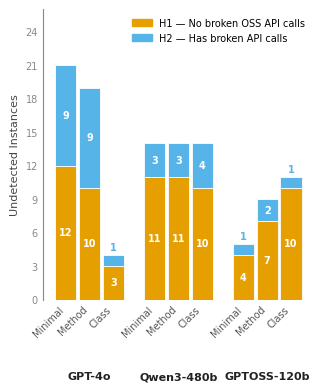

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

# ── Same Wong palette as Venn diagrams ────────────────────────────────────────
H1_COLOR = '#E69F00'  # orange  (was Minimal)
H2_COLOR = '#56B4E9'  # sky blue (was Method)

data = {
    'GPT-4o': {
        'Minimal': (12, 9),
        'Method':  (10, 9),
        'Class':   (3,  1)
    },
    'Qwen3-480b': {
        'Minimal': (11, 3),
        'Method':  (11, 3),
        'Class':   (10, 4)
    },
    'GPTOSS-120b': {
        'Minimal': (4,  1),
        'Method':  (7,  2),
        'Class':   (10, 1)
    }
}

MODELS   = list(data.keys())
VARIANTS = ['Minimal', 'Method', 'Class']

# ── Single-column width: 3.5 in wide, taller to accommodate labels ────────────
fig, ax = plt.subplots(figsize=(3.5, 5))

bar_w           = 0.6
variant_offsets = np.array([-1.12, 0, 1.12]) * bar_w
group_spacing   = 2.5
x               = np.arange(len(MODELS)) * group_spacing

for i, variant in enumerate(VARIANTS):
    xs = x + variant_offsets[i]
    h1 = [data[m][variant][0] for m in MODELS]
    h2 = [data[m][variant][1] for m in MODELS]

    ax.bar(xs, h1, width=bar_w, color=H1_COLOR,
           edgecolor='white', linewidth=0.6, zorder=3)
    ax.bar(xs, h2, bottom=h1, width=bar_w, color=H2_COLOR,
           edgecolor='white', linewidth=0.6, zorder=3)

    for xi, a, b in zip(xs, h1, h2):
        # H1 label
        if a >= 2:
            ax.text(xi, a / 2, str(a),
                    ha='center', va='center',
                    color='white', fontsize=7, fontweight='bold')
        elif a > 0:
            ax.text(xi, a + 0.2, str(a),
                    ha='center', va='bottom',
                    color=H1_COLOR, fontsize=7, fontweight='bold')

        # H2 label
        if b >= 2:
            ax.text(xi, a + b / 2, str(b),
                    ha='center', va='center',
                    color='white', fontsize=7, fontweight='bold')
        elif b > 0:
            ax.text(xi, a + b + 0.2, str(b),
                    ha='center', va='bottom',
                    color=H2_COLOR, fontsize=7, fontweight='bold')

# ── Variant labels under each bar ────────────────────────────────────────────
xticks, xticklabels = [], []
for i in range(len(MODELS)):
    for j in range(len(VARIANTS)):
        xticks.append(x[i] + variant_offsets[j])
        xticklabels.append(VARIANTS[j])

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, fontsize=7, color='#555', rotation=45, ha='right')

# ── Model labels centred under each group ────────────────────────────────────
for xi, model in zip(x, MODELS):
    ax.text(xi, -0.25, model,
            transform=ax.get_xaxis_transform(),
            ha='center', va='top',
            fontsize=8, fontweight='bold', color='#222')

# ── Y-axis ────────────────────────────────────────────────────────────────────
ax.set_ylim(0, 26)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel('Undetected Instances', fontsize=8, color='#444')
ax.yaxis.set_tick_params(labelsize=7, labelcolor='#888')

# ── Spines ────────────────────────────────────────────────────────────────────
for s in ['top', 'right', 'bottom']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color('#888')
ax.spines['left'].set_linewidth(0.8)
ax.tick_params(length=0)
ax.set_axisbelow(True)

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(
    handles=[
        mpatches.Patch(color=H1_COLOR, label='H1 — No broken OSS API calls'),
        mpatches.Patch(color=H2_COLOR, label='H2 — Has broken API calls'),
    ],
    frameon=False, loc='upper right', fontsize=7
)

plt.subplots_adjust(bottom=0.30)
plt.savefig("h1h2_instance_level.pdf", dpi=300, bbox_inches="tight")
plt.savefig("h1h2_instance_level.png", dpi=300, bbox_inches="tight")
plt.show()